# sc-GEM Analysis

In [1]:
cd ..

/home/mscs/congfeng4/GuidedStudy/Code/SCOIT


/public/congfeng4/miniconda3/envs/py39/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import numpy as np
import seaborn as sns
from umap import UMAP
import pandas as pd
import json
import sys
import matplotlib.pyplot as plt

try:
    del sys.modules['hgnn.hypergraph']
except:
    pass

from hgnn.hypergraph import load_graph

DATA = 'sc_GEM'


In [13]:
cell_embeddings = np.load(f'./embeddings/{DATA}/mymodel_0.npy')
gene_embeddings = np.load(f'./embeddings/{DATA}/mymodel_1.npy')
omics_embeddings = np.load(f'./embeddings/{DATA}/mymodel_2.npy')
node_names = pd.read_csv(f'./data/{DATA}/nodes.csv')["Name"]
cell_stage = np.array(pd.read_csv("data/sc_GEM/cell_stage.csv", header=None))[0]
metadata = json.load(open(f'./data/{DATA}/metadata.json'))

In [16]:
NUM_CELLS = metadata['num_cells']
NUM_GENES = metadata['num_genes']
NUM_OMICS = metadata['num_omics']
NUM_CELLS, NUM_GENES, NUM_OMICS

(224, 61, 2)

In [18]:
cell_names = node_names[metadata['cell_offset']:].values
cell_names

array(['BJ_1', 'BJ_11', 'BJ_12', 'BJ_13', 'BJ_14', 'BJ_15', 'BJ_17',
       'BJ_18', 'BJ_19', 'BJ_2', 'BJ_21', 'BJ_22', 'BJ_23', 'BJ_24',
       'BJ_25', 'BJ_26', 'BJ_27', 'BJ_28', 'BJ_29', 'BJ_3', 'BJ_31',
       'BJ_32', 'BJ_34', 'BJ_35', 'BJ_37', 'BJ_4', 'BJ_40', 'BJ_41',
       'BJ_43', 'BJ_44', 'BJ_46', 'BJ_5', 'BJ_7', 'BJ_8', 'BJ_9', 'ES_1',
       'ES_10', 'ES_11', 'ES_12', 'ES_13', 'ES_14', 'ES_15', 'ES_16',
       'ES_17', 'ES_18', 'ES_19', 'ES_2', 'ES_20', 'ES_21', 'ES_22',
       'ES_24', 'ES_25', 'ES_3', 'ES_4', 'ES_5', 'ES_6', 'ES_7', 'ES_8',
       'ES_9', 'IPS_1', 'IPS_10', 'IPS_11', 'IPS_12', 'IPS_13', 'IPS_16',
       'IPS_17', 'IPS_19', 'IPS_2', 'IPS_20', 'IPS_21', 'IPS_22',
       'IPS_23', 'IPS_24', 'IPS_25', 'IPS_26', 'IPS_27', 'IPS_3',
       'IPS_31', 'IPS_32', 'IPS_34', 'IPS_35', 'IPS_36', 'IPS_37',
       'IPS_38', 'IPS_39', 'IPS_4', 'IPS_40', 'IPS_44', 'IPS_45', 'IPS_5',
       'IPS_6', 'IPS_7', 'IPS_8', 'd16T+_1', 'd16T+_10', 'd16T+_11',
       'd16T+_12', 'd

In [24]:
gene_names = node_names[metadata['gene_offset']: metadata['gene_offset'] + metadata['num_genes']].values
len(gene_names)

61

In [5]:
np.unique(cell_stage), len(cell_stage)

(array(['BJ', 'ES', 'IPS', 'd16T+', 'd16T-', 'd24T+', 'd24T-', 'd8'],
       dtype=object),
 224)

## Cell Embeddings

Text(0.5, 1.0, 'UMAP Cell embeddings')

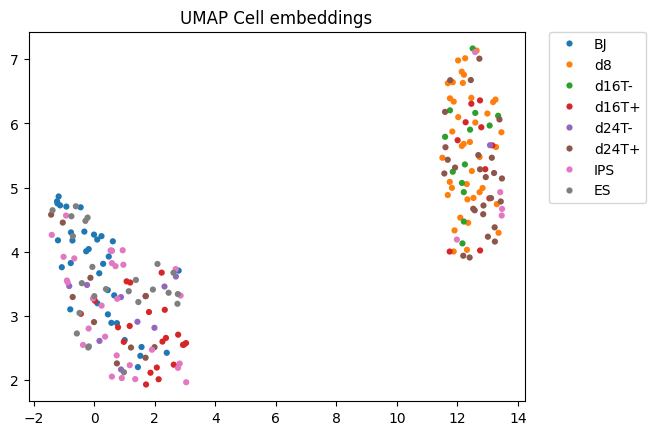

In [7]:
S=20

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

vec = UMAP(n_components=2).fit_transform(cell_embeddings)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage, s=S, linewidth=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=1)
plt.title('UMAP Cell embeddings')

# for xpos, ypos, lb in zip(vec[:, 0], vec[:, 1], hg.cell_names):
#     # Place text slightly offset from the point to avoid overlap
#     plt.text(
#         x=xpos + 10,  # X-position (offset by 10 for readability)
#         y=ypos + 100, # Y-position (offset by 100)
#         s=lb,        # Text to display (e.g., dataname)
#         fontsize=9,
#         color="black"
#     )


## Heatmaps

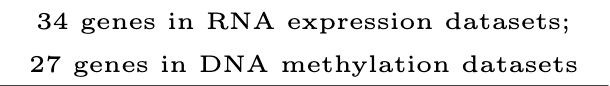

In [8]:
NUM_RNA_EXPR = 34
NUM_DNA_METHY = 27
gene_embeddings.shape

(61, 64)

In [57]:
df_gene = pd.DataFrame(gene_embeddings.T, columns=gene_names)
df_gene

,AFP_expr,BMP7_expr,CDH1_expr,CDX2_expr,CER1_expr,DAZL_expr,DNMT3B_expr,DNMT3L_expr,FGF4_expr,FOSL1_expr,...,NXRA8_methy,PIWIL1_methy,PLEKHH3_methy,STON2P1_methy,SULT1A1_methy,TFAP2A_methy,TMEM173_methy,TNNI3_methy,UNC45A_methy,ZNF662_methy
0,-2.307165,1.813419,1.813062,-4.741152,1.727923,6.803998,1.673647,1.939962,1.278371,0.172210,...,0.873919,0.576553,-1.492875,-0.042513,0.234944,-0.319611,0.733631,0.074568,0.518209,1.121228
1,-0.367974,-0.910620,-0.789485,0.193308,-1.588488,-14.885326,0.094215,1.048935,-0.343531,1.041057,...,-0.480600,-1.028507,0.083271,-0.388400,-0.421703,0.969218,-1.153077,-0.412276,-0.375123,-0.232961
2,0.461952,-1.916016,-0.525856,0.101079,-1.614431,5.814759,-0.679194,0.725540,-0.388151,2.249004,...,-0.527652,-0.699666,0.741376,-1.375404,-0.895716,1.503339,-0.717440,-0.497510,-0.315073,-0.405214
3,-0.186744,-0.484648,-0.645949,0.050464,-0.334977,15.669731,-0.235015,0.275101,-0.619282,0.833287,...,-0.304109,-0.227840,0.357613,-0.256403,-0.520203,0.724736,-0.316174,-0.222787,-0.339923,-0.618971
4,-1.343179,-1.278664,-0.446401,0.347292,0.093109,8.877712,-0.281638,-0.115772,-0.743577,0.974833,...,-0.716677,-1.384096,1.094936,0.683018,-0.936730,1.472407,-0.852187,0.686770,-0.030635,0.752712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,-1.935613,-0.857912,-0.932442,0.390557,-1.546106,10.306317,-0.567709,-0.770656,-1.190526,1.819750,...,-0.337271,-1.089902,1.237186,-0.836239,-0.936367,1.503139,-0.870143,-0.480630,-0.348774,-0.408518
60,0.609049,-1.654693,-0.588418,0.610090,-1.780564,9.248387,-0.425378,-0.100519,-0.904606,1.944920,...,0.437853,-0.493188,2.207267,-0.569985,-0.706954,2.269061,-0.086988,0.762945,0.087509,0.296300
61,-0.026493,-0.006336,0.134605,-0.051967,-0.008176,-15.453582,-0.143842,0.435873,-0.292720,-0.803362,...,0.485356,-0.044934,0.098893,0.273695,0.039802,0.106803,0.299700,0.137677,0.419921,-0.038289
62,-0.487345,0.483566,0.178756,0.408105,0.628947,15.942610,-0.195471,-0.360674,0.415789,-0.530569,...,0.480452,0.660972,-0.405825,0.183394,0.304833,-0.487852,0.996544,0.175735,-0.202578,0.336360


In [51]:
EXPR_LIST = [
    "ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1", "IGF2", "HAND1", "TFAP2A",
    "TBX3", "FOSL1", "LUM", "TGFBR2"
]
METHY_LIST = [
    "CDH22", "KCNQ2", "NXRA8", "DPPA3", "TMEM173", "COL20A1", "TNNI3",
    "CHL1", "STON2P1", "ALDH3A1", "UNC45A", "SULT1A1", "ZNF662", "LTBR",
    "PIWIL1", "CYBRD1", "FOXD2", "HLX-AS1", "ADAM33", "NFIX", "COL23A1",
    "LY86-AS1", "NFATC1", "PLEKHH3", "TFAP2A", "EPHB3", "AK123759"
]
len(EXPR_LIST), len(METHY_LIST)

(26, 27)

## Heatmap of RNA Expression

In [64]:
df_expr = df_gene.loc[:, df_gene.columns.str.endswith('_expr')].rename(lambda x: x.replace('_expr', ''), axis=1)
df_expr = df_expr.loc[:, EXPR_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of RNA expression on sc-GEM')

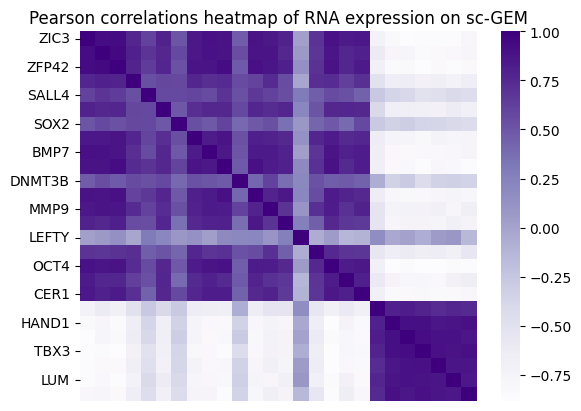

In [80]:
sns.heatmap(df_expr.corr(method='pearson'), cmap='Purples')
plt.xticks([])
plt.title('Pearson correlations heatmap of RNA expression on sc-GEM')

## Heatmap of DNA Methylation

In [76]:
df_methy = df_gene.loc[:, df_gene.columns.str.endswith('_methy')].rename(lambda x: x.replace('_methy', ''), axis=1)
df_methy = df_methy.loc[:, METHY_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of DNA methylation on sc-GEM')

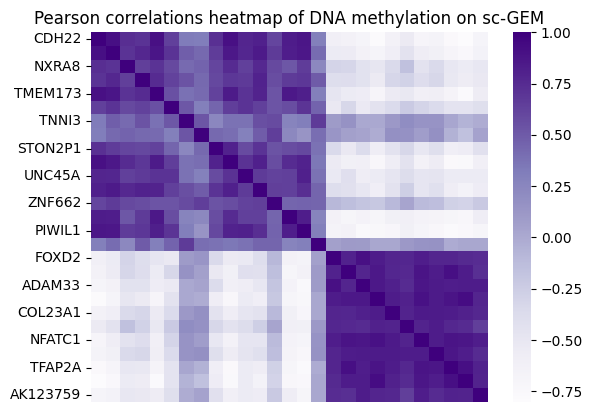

In [81]:
sns.heatmap(df_methy.corr(method='pearson'), cmap='Purples')
plt.xticks([])
plt.title('Pearson correlations heatmap of DNA methylation on sc-GEM')